# 21. Картинки рукописных цифр (1797 × 64 пикселя): где бустинг — не лучший выбор

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`21_digits_images.py`](../21_digits_images.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 19 с |

**Цель.** Понять границы применимости бустинга на реальных нетабличных данных.

### Чему вы научитесь

- Разбор набора-изображения: пиксели как признаки
- Многоклассовый бустинг на 10 классах
- Честное сравнение с логистической регрессией, случайным лесом и SVM
- Время обучения
- Матрица ошибок

### Данные

`sklearn.datasets.load_digits` — 1797 изображений 8×8 рукописных цифр 0–9 (яркость 0–16 в каждом из 64 пикселей). Встроен в scikit-learn.

### План

1. **Этап 1.** Данные
2. **Этап 2.** 5-кратная кросс-валидация: точность и время
3. **Этап 3.** Какие цифры путает LightGBM
4. **Этап 4.** Выводы

> Ноутбук собран из `examples/3_medium/21_digits_images.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "3_medium/21_digits_images.py", title="21. Рукописные цифры: где бустинг не лучший",
             goal="сравнить бустинг с другими моделями на изображениях")

import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

## Этап 1. Данные

   Источник: sklearn.datasets.load_digits (UCI) — показаны первые 8 из 64 пикселей
   Объектов: 1 797   признаков: 8   память: 0.11 МБ
   Типы признаков: float64 × 8
   Пропусков нет
   Цель «цифра»: класс 0 — 178 (9.9%), класс 1 — 182 (10.1%), класс 2 — 177 (9.8%), класс 3 — 183 (10.2%), класс 4 — 181 (10.1%), класс 5 — 182 (10.1%), класс 6 — 181 (10.1%), класс 7 — 179 (10.0%), класс 8 — 174 (9.7%), класс 9 — 180 (10.0%)
   Первые строки:


,пиксель_0,пиксель_1,пиксель_2,пиксель_3,пиксель_4,пиксель_5,пиксель_6,пиксель_7,[цифра]
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,2


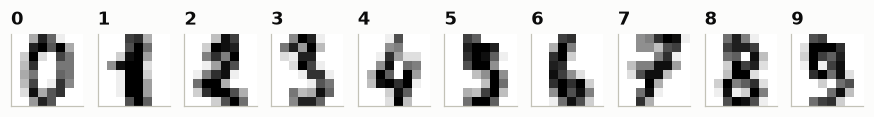

In [2]:
X, y = load_digits(return_X_y=True)
ex.describe(X[:, :8], y, names=[f"пиксель_{j}" for j in range(8)], target="цифра", task="classification",
            source="sklearn.datasets.load_digits (UCI) — показаны первые 8 из 64 пикселей")
fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for d, ax in enumerate(axes):
    ax.imshow(X[y == d][0].reshape(8, 8), cmap="gray_r")
    ax.set(xticks=[], yticks=[], title=str(d))
ex.finish(fig, "21_digits")

## Этап 2. 5-кратная кросс-валидация: точность и время

In [3]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
models = {
    "логистическая регрессия": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "случайный лес": RandomForestClassifier(500, random_state=0, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0),
    "LightGBM": lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=15, min_child_samples=5, verbose=-1, random_state=0),
    "SVM (RBF-ядро)": make_pipeline(StandardScaler(), SVC()),
}
acc = {}
for name, m in models.items():
    t = time.perf_counter()
    a = cross_val_score(m, X, y, cv=cv)
    acc[name] = a.mean()
    print(f"   {name:24s} точность {a.mean():.4f} ± {a.std():.4f}   ({time.perf_counter() - t:.1f} с)")
ex.note("SVM с RBF-ядром лучший и в 10–20 раз быстрее бустинга; бустинг не обгоняет даже случайный лес.")
assert acc["SVM (RBF-ядро)"] > acc["LightGBM"]

   логистическая регрессия  точность 0.9694 ± 0.0099   (0.1 с)


   случайный лес            точность 0.9761 ± 0.0058   (2.7 с)


   HistGradientBoosting     точность 0.9733 ± 0.0058   (5.7 с)


   LightGBM                 точность 0.9683 ± 0.0072   (4.0 с)
   SVM (RBF-ядро)           точность 0.9805 ± 0.0072   (0.2 с)


> ▸ **Вывод.** SVM с RBF-ядром лучший и в 10–20 раз быстрее бустинга; бустинг не обгоняет даже случайный лес.

## Этап 3. Какие цифры путает LightGBM

In [4]:
pred = cross_val_predict(models["LightGBM"], X, y, cv=cv)
cm = confusion_matrix(y, pred)
np.fill_diagonal(cm, 0)
pairs = sorted(((cm[i, j], i, j) for i in range(10) for j in range(10) if cm[i, j]), reverse=True)[:4]
for c, i, j in pairs:
    print(f"   {i} → {j}: ошибок {c}")

   8 → 1: ошибок 5
   5 → 9: ошибок 5
   3 → 5: ошибок 4
   9 → 8: ошибок 3


## Этап 4. Выводы

In [5]:
ex.note("""Пиксели — однородные признаки, важна пространственная структура (соседство пикселей, сдвиги).
Деревья смотрят на пиксели по одному и этой структуры не видят; для изображений лучше ядра и свёрточные сети.
Бустинг — лучший выбор для разнородных табличных признаков: цены, категории, счётчики, даты.""")
ex.done()

> ▸ **Вывод.** Пиксели — однородные признаки, важна пространственная структура (соседство пикселей, сдвиги). Деревья смотрят на пиксели по одному и этой структуры не видят; для изображений лучше ядра и свёрточные сети. Бустинг — лучший выбор для разнородных табличных признаков: цены, категории, счётчики, даты.

Готово за 17.8 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Добавьте признаки-суммы по строкам и столбцам изображения — догонит ли бустинг SVM?
2. Нарисуйте важность 64 пикселей для LightGBM картой 8×8.
3. Обучите модели на 300 изображениях вместо 1437 — чья точность падает сильнее?

## Что дальше

- **Теория в курсе:** [6.3 «Многоклассовая классификация»](../../../lessons/lesson_6_3/README.md), [9.4 «Сравнение»](../../../lessons/lesson_9_4/README.md).
- **Предыдущий пример:** [20. Интерпретация модели с SHAP: от общей картины до одной квартиры](20_shap_interpretation.ipynb)
- **Следующий пример:** [22. Миллион строк: скорость обучения и прогноза, память, потоки](../../4_large/notebooks/22_million_rows_speed.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)